In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import re
from datetime import datetime
import string
from scipy.stats import gaussian_kde
import numpy as np
# 

In [92]:
sys.path.append('Utils/')
from PlotUtils import (setMplParam, 
                       getColour, 
                       getHatch, 
                       getHistoParam, 
                       enable_histogram_counts)
# getHistoParam: 
# Nbins, binwidth, bins, counts, bin_centers  = 
from ExternalFunctions import nice_string_output, add_text_to_ax
setMplParam()
# from DataPipelineWorkShop import get_hourly_example, MeteoPreprocessor

In [93]:
base = Path("/home/cyan_white_tower/projects/MeteoFormer/test_results")

TEST_RESIDUAL_PATTERN = re.compile(
    r"(?P<ckpt_tag>(?:epoch-\d+-val_loss-[0-9.]+|last))"
    r"_test_residuals\.(?P<extension>csv|csv\.gz|parquet)$"
)

In [94]:
runs_speed = {
    "vanila_sin_rope (72-12, 1e-4)": base / "20260529" / "170506",
    "vanila_sin_rope (72-12, 3e-5)": base / "20260529" / "171411",
    "vanila_sin_rope (72-12, 5e-5)": base / "20260529" / "174259",
}
runs_direction = {
    "vanila_sin_rope (72-12, 1e-5)": base / "20260529" / "183118",
    "vanila_sin_rope (72-12, 3e-5)": base / "20260529" / "185646",
}

In [95]:
def parse_test_residual_filename(
    file_path: str | Path,
    base: Path,
) -> dict:
    file_path = Path(file_path)

    match = TEST_RESIDUAL_PATTERN.match(file_path.name)
    if not match:
        raise ValueError(
            f"Filename does not match expected test residual pattern: {file_path.name}"
        )

    info = match.groupdict()

    relative_path = file_path.relative_to(base)

    # Expected structure:
    # test_results/{run_date}/{run_time}/{filename}
    info["run_date"] = relative_path.parts[0]
    info["run_time"] = relative_path.parts[1]

    info["path"] = file_path
    info["relative_path"] = relative_path

    info["run_datetime"] = datetime.strptime(
        info["run_date"] + info["run_time"],
        "%Y%m%d%H%M%S",
    )

    ckpt_tag = info["ckpt_tag"]

    if ckpt_tag == "last":
        info["checkpoint_type"] = "last"
        info["epoch"] = None
        info["val_loss"] = None
    else:
        info["checkpoint_type"] = "epoch"

        epoch_match = re.search(r"epoch-(\d+)", ckpt_tag)
        val_loss_match = re.search(r"val_loss-([0-9.]+)", ckpt_tag)

        info["epoch"] = int(epoch_match.group(1)) if epoch_match else None
        info["val_loss"] = float(val_loss_match.group(1)) if val_loss_match else None

    return info

In [96]:
def select_best_residual_file(
    files: list[Path],
    base: Path,
) -> Path:
    """
    Select the residual file with the lowest validation loss.

    Files with val_loss=None, e.g. 'last', are ignored unless no epoch files exist.
    """
    parsed = []

    for file_path in files:
        info = parse_test_residual_filename(file_path, base=base)
        parsed.append((file_path, info))

    # Prefer files with actual validation loss
    epoch_files = [
        (file_path, info)
        for file_path, info in parsed
        if info["val_loss"] is not None
    ]

    if epoch_files:
        best_file, best_info = min(
            epoch_files,
            key=lambda item: item[1]["val_loss"],
        )
        return best_file

    # Fallback: if only "last" exists
    return parsed[0][0]

In [97]:
def find_test_residual_files(run_dir: str | Path) -> list[Path]:
    run_dir = Path(run_dir)

    if not run_dir.exists():
        raise FileNotFoundError(f"Run directory does not exist: {run_dir}")

    files = []
    files.extend(run_dir.glob("*_test_residuals.parquet"))
    files.extend(run_dir.glob("*_test_residuals.csv"))
    files.extend(run_dir.glob("*_test_residuals.csv.gz"))

    files = sorted(files)

    if not files:
        raise FileNotFoundError(f"No residual files found in: {run_dir}")

    return files

In [98]:
def read_residual_file(file_path: str | Path) -> pd.DataFrame:
    file_path = Path(file_path)

    if file_path.suffix == ".parquet":
        return pd.read_parquet(file_path)

    if file_path.name.endswith(".csv.gz"):
        return pd.read_csv(file_path, compression="gzip")

    if file_path.suffix == ".csv":
        return pd.read_csv(file_path)

    raise ValueError(f"Unsupported file type: {file_path}")

In [99]:
def load_test_residuals_from_runs(
    runs: dict[str, Path],
    base: Path,
    best_only: bool = True,
) -> pd.DataFrame:
    all_dfs = []
    group_counter = 0

    for run_label, run_dir in runs.items():
        files = find_test_residual_files(run_dir)

        if best_only:
            files = [select_best_residual_file(files, base=base)]

        for file_path in files:
            info = parse_test_residual_filename(file_path, base=base)
            df = read_residual_file(file_path)

            group_id = string.ascii_uppercase[group_counter]

            df["group_id"] = group_id
            df["run_label"] = run_label
            df["run_date"] = info["run_date"]
            df["run_time"] = info["run_time"]
            df["ckpt_tag"] = info["ckpt_tag"]
            df["epoch"] = info["epoch"]
            df["val_loss"] = info["val_loss"]
            df["source_file"] = str(file_path)

            all_dfs.append(df)
            group_counter += 1

    if not all_dfs:
        raise ValueError("No residual data loaded.")

    return pd.concat(all_dfs, ignore_index=True)

In [100]:
def make_plot_label(run_label: str, ckpt_tag: str, epoch, val_loss) -> str:
    if epoch is not None and val_loss is not None:
        return f"{run_label} | epoch {epoch} | val_loss={val_loss:.4f}"
    return f"{run_label} | {ckpt_tag}"

In [101]:
def bootstrap_metric_ci(
    x: np.ndarray,
    metric_fn,
    n_bootstrap: int = 1000,
    ci: float = 0.95,
    random_state: int = 42,
):
    x = np.asarray(x)
    x = x[np.isfinite(x)]

    rng = np.random.default_rng(random_state)
    values = []

    for _ in range(n_bootstrap):
        xb = rng.choice(x, size=len(x), replace=True)
        values.append(metric_fn(xb))

    values = np.asarray(values)

    alpha = 1.0 - ci
    lower = np.percentile(values, 100 * alpha / 2)
    upper = np.percentile(values, 100 * (1 - alpha / 2))

    return values.mean(), lower, upper

In [102]:
def bootstrap_kde_band(
    x: np.ndarray,
    x_grid: np.ndarray,
    bandwidth: float | None = None,
    n_bootstrap: int = 30,
    ci: float = 0.95,
    random_state: int = 42,
):
    x = np.asarray(x)
    x = x[np.isfinite(x)]

    rng = np.random.default_rng(random_state)

    y_boot = []

    for _ in range(n_bootstrap):
        xb = rng.choice(x, size=len(x), replace=True)

        kde_b = gaussian_kde(xb)

        if bandwidth is not None:
            kde_b.set_bandwidth(bw_method=bandwidth)

        y_boot.append(kde_b(x_grid))

    y_boot = np.asarray(y_boot)

    alpha = 1.0 - ci
    y_low = np.percentile(y_boot, 100 * alpha / 2, axis=0)
    y_high = np.percentile(y_boot, 100 * (1 - alpha / 2), axis=0)

    return y_low, y_high

In [103]:
def plot_all_residual_distribution_kde(
    df_all: pd.DataFrame,
    bandwidth: float | None = None,
    y_max: float = 1.0,
    n_grid: int = 100,
    scale_to_counts: bool = False,
    reference_binwidth: float = 0.333,
):
    def make_hist_stat_dict(
        group_id: str,
        x: pd.Series,
        rmse_mean: float,
        rmse_low: float,
        rmse_high: float,
    ) -> dict:
        return {
            f"N {group_id}": len(x),
            f"mean {group_id}": x.mean(),
            f"median {group_id}": x.median(),
            f"std {group_id}": x.std(),
            f"RMSE {group_id}": rmse_mean,
            # f"RMSE {group_id}": f"{rmse_mean:.3f} [{rmse_low:.3f}, {rmse_high:.3f}]"
        }

    fig, ax = plt.subplots(figsize=(13, 11))

    grouped = df_all.groupby(
        ["group_id", "run_label", "ckpt_tag", "epoch", "val_loss"],
        dropna=False,
    )

    stat_blocks = []

    # Determine shared x-range from all residuals
    residuals_all = df_all["residual"].dropna()

    x_min = residuals_all.quantile(0.001)
    x_max = residuals_all.quantile(0.999)

    x_grid = np.linspace(x_min, x_max, n_grid)

    for i, ((group_id, run_label, ckpt_tag, epoch, val_loss), df_group) in enumerate(grouped):
        x = df_group["residual"].dropna()

        if len(x) < 2:
            continue

        label = f"{group_id}: {make_plot_label(run_label, ckpt_tag, epoch, val_loss)}"

        kde = gaussian_kde(x)

        if bandwidth is not None:
            kde.set_bandwidth(bw_method=bandwidth)

        y = kde(x_grid)

        if scale_to_counts:
            # Convert probability density to approximate histogram counts
            # so the y-axis remains comparable to your histogram version.
            y = y * len(x) * reference_binwidth
            ax.set_ylabel("Approx. counts")
        else:
            ax.set_ylabel("Density")
        
        y_low, y_high = bootstrap_kde_band(
            x.to_numpy(),
            x_grid,
            bandwidth=bandwidth,
            n_bootstrap=30,
            ci=0.95,
            random_state=42 + i,
        )

        ax.plot(
            x_grid,
            y,
            label=label,
            linewidth=2,
            marker=""
        )
        
        ax.fill_between(
            x_grid,
            y_low,
            y_high,
            alpha=0.33,
            linewidth=0,
        )

        rmse_mean, rmse_low, rmse_high = bootstrap_metric_ci(
            x,
            metric_fn=lambda r: np.sqrt(np.mean(r**2)),
            n_bootstrap=1000,
            ci=0.95,
        )
        d = make_hist_stat_dict(
            group_id,
            x,
            rmse_mean,
            rmse_low,
            rmse_high,
        )
        stat_blocks.append(nice_string_output(d, decimals=3))

    ax.set_xlabel("Residuals")
    ax.set_title("KDE of Test residual distribution")
    ax.legend(fontsize=12, loc="upper right")
    ax.set_ylim(0, y_max)

    split_idx = 8

    stat_text_left = "\n\n".join(stat_blocks[:split_idx])
    stat_text_right = "\n\n".join(stat_blocks[split_idx:])

    add_text_to_ax(
        0.02,
        0.98,
        stat_text_left,
        ax,
        fontsize=12,
    )

    if len(stat_blocks) > split_idx:
        add_text_to_ax(
            0.72,
            0.60,
            stat_text_right,
            ax,
            fontsize=12,
        )

In [104]:
df_speed = load_test_residuals_from_runs(runs_speed, base=base)
df_direction = load_test_residuals_from_runs(runs_direction, base=base)

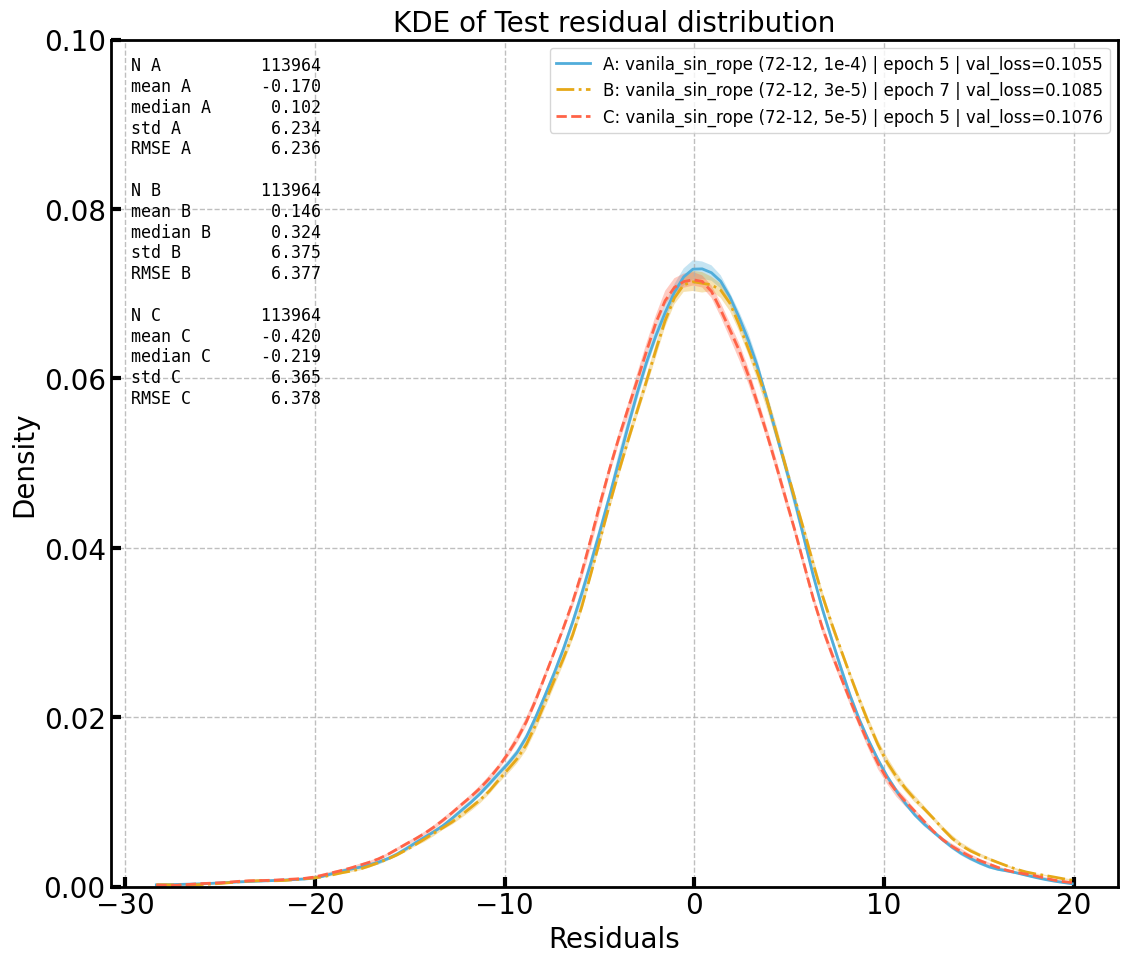

In [105]:
plot_all_residual_distribution_kde(df_speed, y_max=0.10)
# < 15 sec

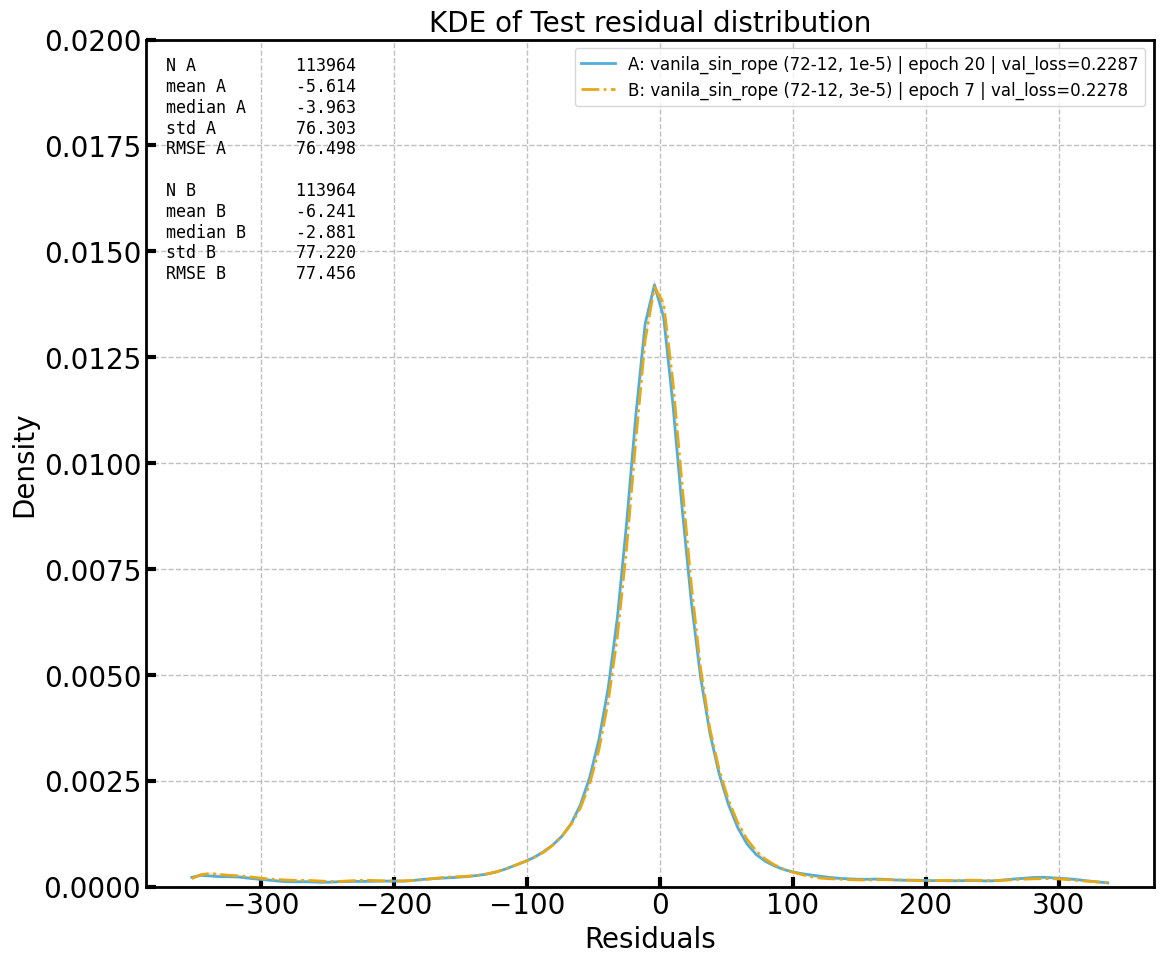

In [110]:
plot_all_residual_distribution_kde(df_direction, y_max=0.02)

In [107]:
def compute_horizon_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute error metrics grouped by forecast lead time.

    Assumes df contains:
        lead_time, residual, abs_error, squared_error
    """
    horizon_stats = (
        df.groupby("lead_time")
        .agg(
            n_points=("residual", "count"),
            mse=("squared_error", "mean"),
            mae=("abs_error", "mean"),
            bias=("residual", "mean"),
            residual_std=("residual", "std"),
            median_abs_error=("abs_error", "median"),
        )
        .reset_index()
    )

    horizon_stats["rmse"] = horizon_stats["mse"] ** 0.5

    return horizon_stats

In [108]:
def plot_horizon_metrics(
    df_all: pd.DataFrame,
    metric: str = "rmse",
):
    fig, ax = plt.subplots(figsize=(13, 8))

    grouped = df_all.groupby(
        ["group_id", "run_label", "ckpt_tag", "epoch", "val_loss"],
        dropna=False,
    )

    stat_blocks = []

    for i, ((group_id, run_label, ckpt_tag, epoch, val_loss), df_group) in enumerate(grouped):
        horizon_stats = compute_horizon_metrics(df_group)

        label = f"{group_id}: {make_plot_label(run_label, ckpt_tag, epoch, val_loss)}"

        ax.plot(
            horizon_stats["lead_time"],
            horizon_stats[metric],
            label=label,
            # **getHistStyle(i, filled=False),  # if you made this helper
        )

        d = {
            f"{group_id} mean {metric}": horizon_stats[metric].mean(),
            f"{group_id} max {metric}": horizon_stats[metric].max(),
        }
        stat_blocks.append(nice_string_output(d, decimals=3))

    ax.set_xlabel("Forecast lead time [hour]")
    ax.set_ylabel(metric.upper())
    ax.set_title(f"{metric.upper()} by forecast horizon")
    ax.legend(fontsize=12, loc="lower right")

    add_text_to_ax(
        0.02,
        0.95,
        "\n\n".join(stat_blocks),
        ax,
        fontsize=12,
    )

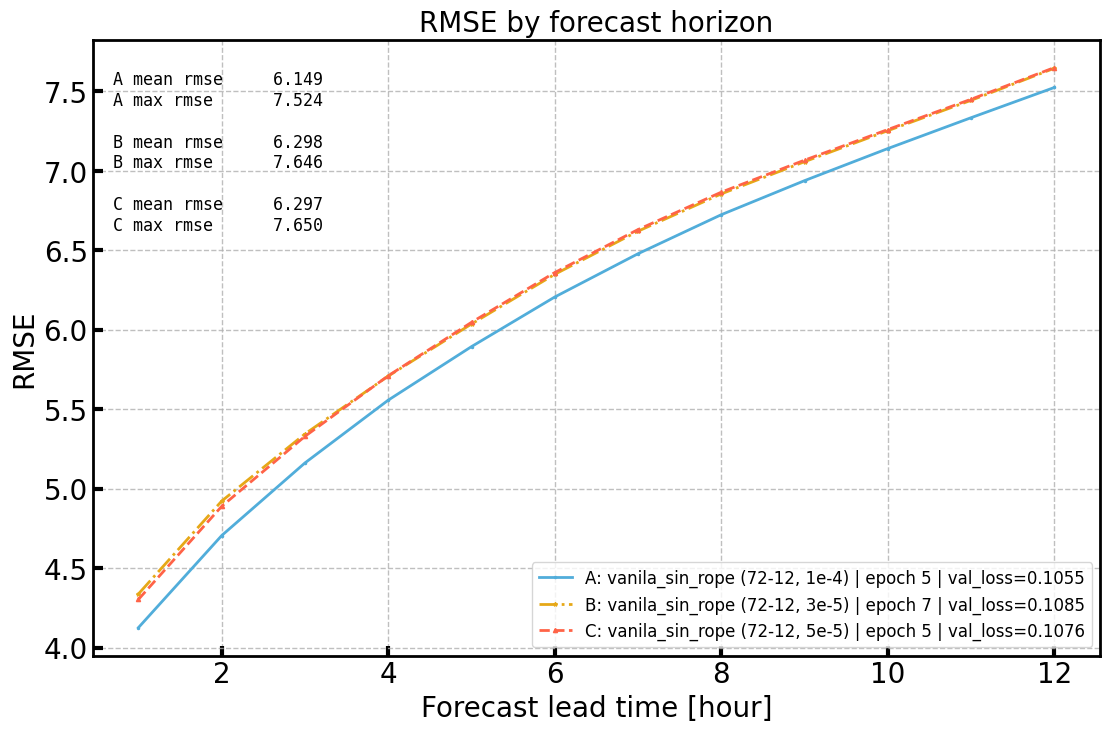

In [109]:
plot_horizon_metrics(df_speed)

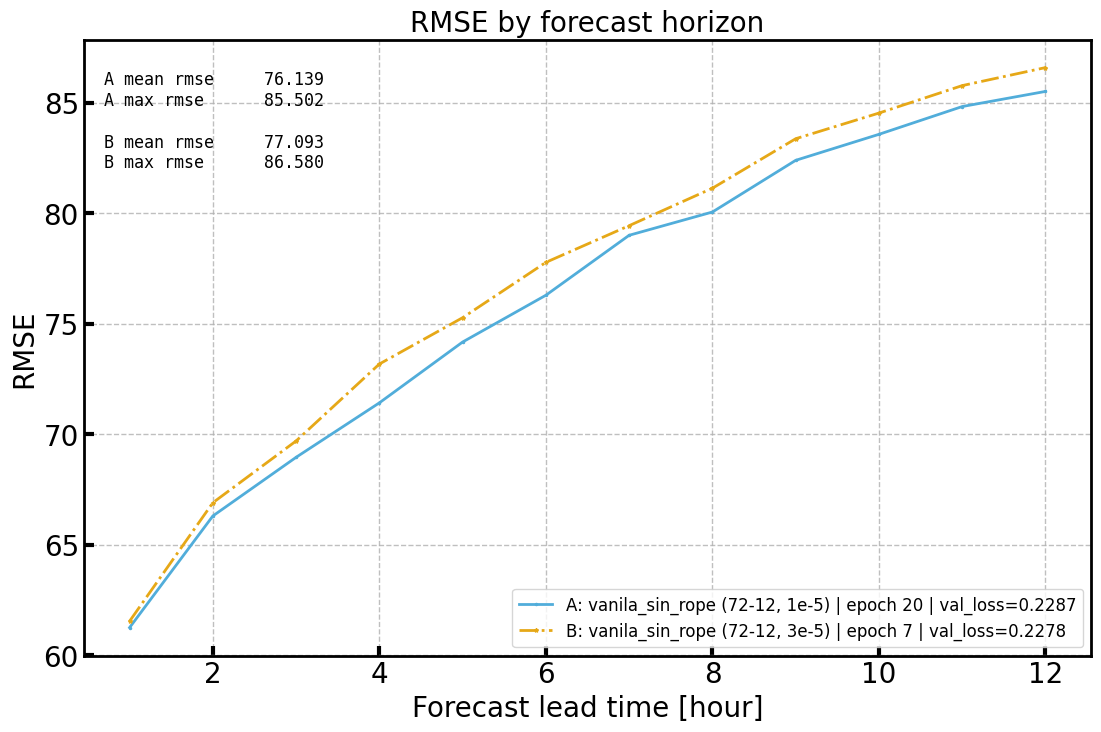

In [111]:
plot_horizon_metrics(df_direction)